In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

In [2]:
color1 = cm.inferno_r(np.linspace(.4, .8, 30))
color2 = cm.magma_r(np.linspace(.4, .8, 30))
color3 = cm.summer(np.linspace(.4, .8, 30))
ordem = [ 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']


In [3]:
df = pd.read_csv('data-treatment.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465676 entries, 0 to 1465675
Data columns (total 31 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   data_inversa            1465676 non-null  str    
 1   dia_semana              1465676 non-null  str    
 2   horario                 1465676 non-null  str    
 3   uf                      1465676 non-null  str    
 4   br                      1465676 non-null  int64  
 5   km                      1465676 non-null  float64
 6   municipio               1465676 non-null  str    
 7   causa_acidente          1465676 non-null  str    
 8   tipo_acidente           1465676 non-null  str    
 9   classificacao_acidente  1465676 non-null  str    
 10  fase_dia                1465676 non-null  str    
 11  sentido_via             1465676 non-null  str    
 12  condicao_metereologica  1465676 non-null  str    
 13  tipo_pista              1465676 non-null  str    
 14  tracado_via  

In [5]:
# Apenas uma correção, dado que o csv não mantém os tipos das colunas
df['br'] = df['br'].astype(str)
df['km_int'] = df['km_int'].astype(str)
df['ano'] = df['ano'].astype(str)

In [6]:
df.describe().round(2)

,km,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,mes,horas,dia
count,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00
mean,262.29,2.15,0.05,0.43,0.16,1.43,0.08,0.59,1.75,6.57,13.05,15.64
std,230.12,1.54,0.28,0.97,0.56,1.21,0.38,1.19,0.72,3.49,5.82,8.76
min,-870.30,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00
25%,79.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,4.00,8.00,8.00
50%,202.80,2.00,0.00,0.00,0.00,1.00,0.00,0.00,2.00,7.00,14.00,16.00
75%,411.50,2.00,0.00,1.00,0.00,2.00,0.00,1.00,2.00,10.00,18.00,23.00
max,9967.10,248.00,33.00,52.00,222.00,99.00,86.00,239.00,25.00,12.00,23.00,31.00


In [7]:
def plot_bar(a: pd.Series):

    fig, ax = plt.subplots(figsize=(9,3), layout="constrained")

    ax.bar(a.index, a.values, linewidth=0.7, color=color1)

    ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

    ax.tick_params("x", rotation=45)

    plt.show()

- Quais são os 10 estados com maior número de acidentes registrados?

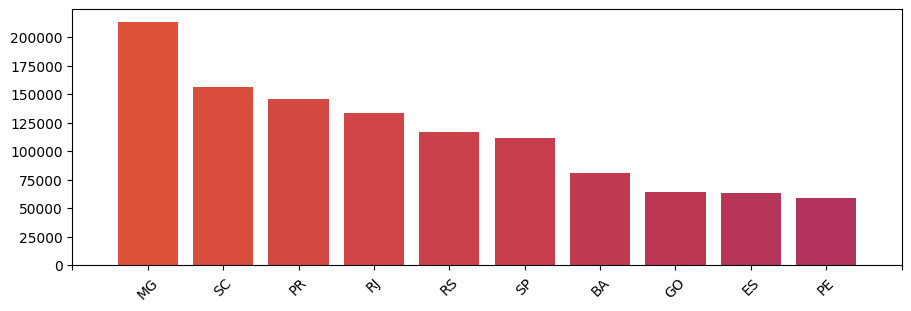

In [8]:
analysis = df.groupby(['uf']).size().sort_values(ascending=False)
plot_bar(analysis[:10])

- Condições metereológicas com mais acidentes

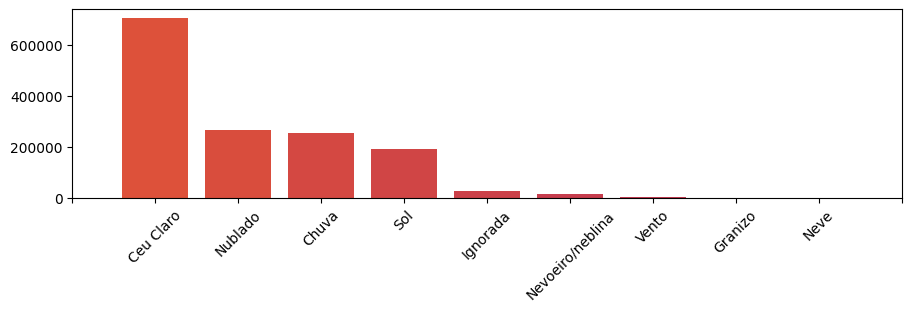

In [9]:
a = df.groupby(['condicao_metereologica']).size().sort_values(ascending=False)
plot_bar(a)

- Horários com mais acidentes

Podemos perceber que no horário comercial é onde concentramos mais acidentes, com um certo pico às 7, horário em que o pessoal está se deslocando para o trabalho e às 18h, com um pico maior, horário que o pessoal está voltando para casa

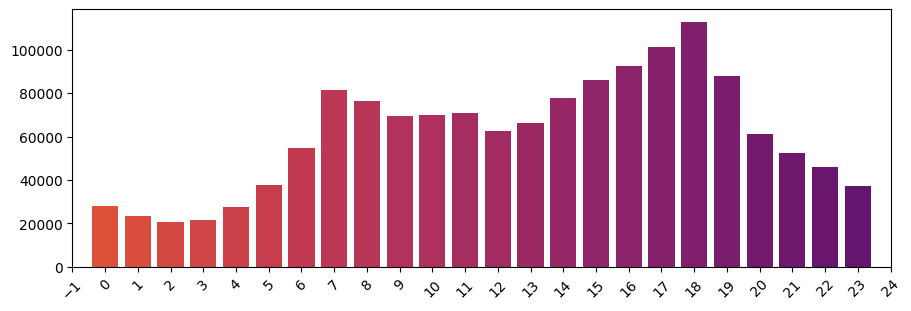

In [10]:
a= df.groupby(['horas'])['horas'].size()

plot_bar(a)

- Quantidade de acidentes ao longo dos anos

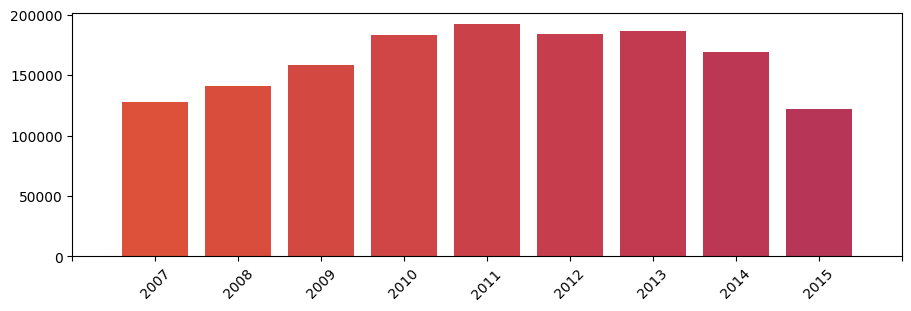

In [11]:
a = df.groupby(['ano'])['ano'].size()

plot_bar(a)

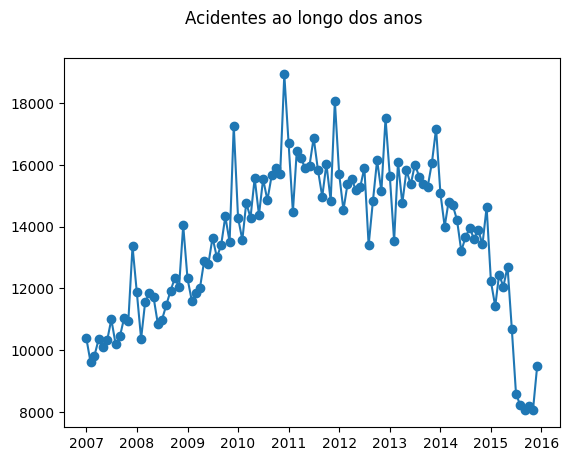

In [12]:
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

a = df.groupby(['ano_mes'])['ano_mes'].size()

fig = plt.figure()

fig.suptitle('Acidentes ao longo dos anos')

ax = fig.add_subplot()

ax.plot(a.index, a.values, '-o')

#ax.set(xticks=np.arange(1, len(lista_series)+1))

plt.show()

- Qual é a distribuição de acidentes por dia da semana?

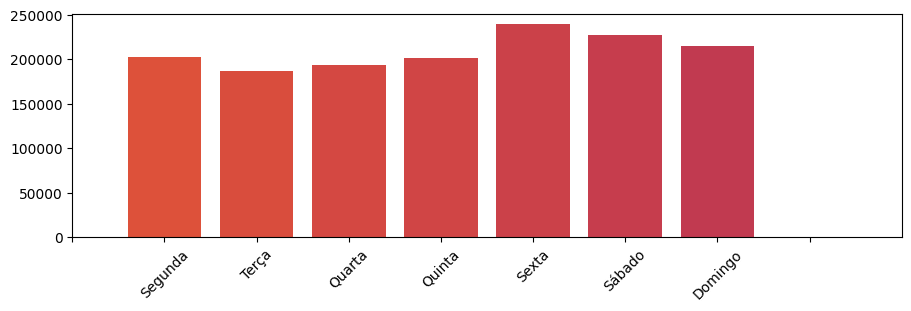

In [13]:
a = df.groupby(by=['dia_semana']).size()
a = a.reindex(ordem)
plot_bar(a)

- Quais meses do ano concentram mais acidentes e mortes?

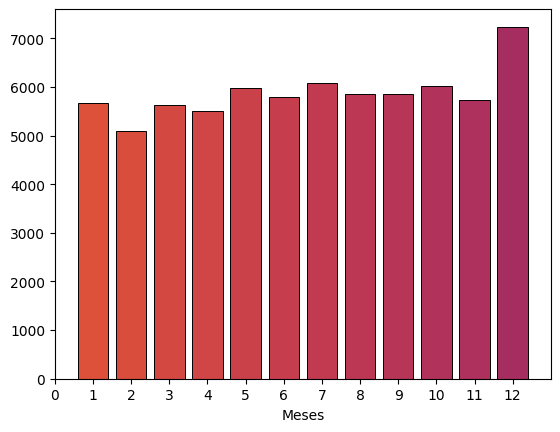

In [14]:
a = df.groupby(['mes'])['mortos'].sum()

fig, ax = plt.subplots()

ax.bar(a.index, a.values, edgecolor='blacK', linewidth=0.7, color=color1)

ax.set(xlim = (0, len(a.index)+1), xticks=np.arange(0, len(a.index)+1))

plt.xlabel('Meses')

plt.show()


- Existe interação entre dia da semana e horário que eleva a gravidade dos acidentes?

Pior que não vemos isso não, todos os dias da semana apresentam o mesmo comportamento com um pico de acidentes entre as 18-19h que aumentam a gravidade, como observado em uma das análises anteriores

In [15]:
n = df.groupby(['dia_semana', 'horas', 'classificacao_acidente']).size()
d = df.groupby(['dia_semana','classificacao_acidente']).size()

p = ((n/d)*100).round(2)
p=p.unstack(level=1)

p.reindex(ordem, level=0)

horas                                0     1     2     3     4     5     6   \
dia_semana classificacao_acidente                                             
Segunda    Com Vítimas Fatais      4.19  3.20  2.84  2.36  2.78  4.67  5.54   
           Com Vítimas Feridas     2.47  1.83  1.43  1.21  1.45  2.53  4.87   
           Ignorado                6.70  6.13  5.94  4.43  5.00  6.60  5.85   
           Sem Vítimas             1.56  1.19  0.94  1.01  1.33  2.17  4.30   
Terça      Com Vítimas Fatais      2.46  1.86  1.96  1.81  2.70  3.66  4.31   
           Com Vítimas Feridas     1.42  1.19  0.94  0.99  1.50  2.32  4.15   
           Ignorado                4.18  4.51  2.90  3.65  3.86  5.47  3.86   
           Sem Vítimas             1.35  1.10  0.96  0.96  1.26  2.03  3.51   
Quarta     Com Vítimas Fatais      2.48  2.03  1.83  2.03  2.42  4.31  5.01   
           Com Vítimas Feridas     1.59  1.21  1.01  1.08  1.44  2.20  4.21   
           Ignorado                6.25  4.00  3.69  4.20  4.82  5.74  4.51   
           Sem Vítimas             1.41  1.16  1.03  1.03  1.27  2.01  3.57   
Quinta     Com Vítimas Fatais      2.99  2.39  2.10  1.95  3.08  4.07  4.65   
           Com Vítimas Feridas     1.77  1.42  1.24  1.17  1.59  2.46  4.30   
           Ignorado                4.96  3.28  4.12  4.40  4.78  6.27  5.15   
           Sem Vítimas             1.54  1.27  1.10  1.04  1.47  2.10  3.56   
Sexta      Com Vítimas Fatais      2.20  2.32  1.98  2.14  2.91  3.97  4.64   
           Com Vítimas Feridas     1.72  1.40  1.21  1.37  1.70  2.25  3.81   
           Ignorado                4.66  5.33  3.55  4.96  6.44  6.00  5.40   
           Sem Vítimas             1.45  1.15  1.02  1.09  1.34  2.02  3.16   
Sábado     Com Vítimas Fatais      3.42  3.28  2.94  3.14  4.40  4.39  4.11   
           Com Vítimas Feridas     2.48  2.17  2.11  2.17  2.88  3.48  3.57   
           Ignorado                4.24  4.80  5.73  5.50  6.61  8.24  6.71   
           Sem Vítimas             2.44  1.96  1.74  1.75  2.42  2.93  3.64   
Domingo    Com Vítimas Fatais      3.69  3.14  3.18  3.81  4.88  4.71  3.56   
           Com Vítimas Feridas     2.76  2.50  2.46  2.76  3.29  3.67  3.38   
           Ignorado                4.33  5.30  4.78  6.64  8.10  8.10  6.80   
           Sem Vítimas             2.24  2.02  1.67  1.92  2.22  2.84  2.97   

horas                                7     8     9   ...    14    15    16  \
dia_semana classificacao_acidente                    ...                     
Segunda    Com Vítimas Fatais      4.54  3.97  3.06  ...  4.33  4.14  4.38   
           Com Vítimas Feridas     7.28  5.65  4.59  ...  5.15  5.35  5.70   
           Ignorado                4.25  3.49  3.02  ...  3.02  3.11  4.34   
           Sem Vítimas             7.50  6.86  5.90  ...  5.68  6.18  6.28   
Terça      Com Vítimas Fatais      4.39  3.50  3.35  ...  4.58  4.78  4.42   
           Com Vítimas Feridas     6.86  5.69  4.68  ...  5.45  5.64  5.74   
           Ignorado                4.51  3.22  3.00  ...  3.11  4.18  3.97   
           Sem Vítimas             6.34  6.45  5.71  ...  5.73  6.33  6.54   
Quarta     Com Vítimas Fatais      4.43  3.58  2.94  ...  4.59  4.81  4.83   
           Com Vítimas Feridas     6.90  5.38  4.62  ...  5.40  5.36  5.81   
           Ignorado                4.20  3.28  3.07  ...  2.66  2.97  3.79   
           Sem Vítimas             6.30  6.27  5.52  ...  5.72  6.25  6.43   
Quinta     Com Vítimas Fatais      4.31  3.56  3.11  ...  4.35  4.38  4.40   
           Com Vítimas Feridas     6.66  5.33  4.43  ...  5.27  5.24  5.72   
           Ignorado                5.24  3.28  4.21  ...  3.56  4.03  3.75   
           Sem Vítimas             6.21  6.24  5.53  ...  5.71  6.21  6.46   
Sexta      Com Vítimas Fatais      3.98  2.72  2.28  ...  3.50  3.99  4.35   
           Com Vítimas Feridas     5.80  4.59  4.03  ...  4.88  5.40  6.34   
           Ignorado                3.26  2.89  3.11  ...  2.37  2.89 

- A redução de acidentes ao longo dos anos é uniforme entre estados ou concentrada em alguns?

Como podemos ver no dataframe abaixo, na maioria dos estados ocorreu sim uma redução do número de acidentes ao longo dos anos, porém, com uma variação diferente. Além disso, podemos perceber um comportamento em muitos dos estados, de uma subida no número de acidentes de 2009 a 2014, e finalmente com uma diminuída até 2016.

São poucos os estados que não seguem esse comportamento, ou até mesmo o a redução final, tais estados como: AP, AC, MS e TO, por exemplo, que passaram por esse pico de acidentes comentados anteriormente, porém ao final não representou uma diminuição em relação ao começo, terminado com uma % acima do valor inicial, em muitos casos bem pequena, sendo a maior delas o TO, com 17% de aumento em relação ao valor inicial

In [16]:
df.groupby(['uf', 'ano']).size().unstack(level=-1)

ano,2007,2008,2009,2010,2011,2012,2013,2014,2015
uf,,,,,,,,,
AC,324,353,365,462,518,503,448,457,468
AL,1604,1778,1914,2276,2364,2195,2375,1528,1071
AM,173,194,199,239,249,218,234,168,131
AP,150,168,161,162,232,241,277,273,218
BA,7085,7628,8208,9440,10433,10279,10388,10404,7152
CE,2260,2691,2913,3784,3824,3746,4010,3791,2636
DF,1137,1044,1228,1299,1583,1448,1535,1327,1040
ES,6239,6381,6746,7830,7952,7718,8217,7805,4762
GO,5607,6452,7179,8012,8060,7691,7986,7125,6131


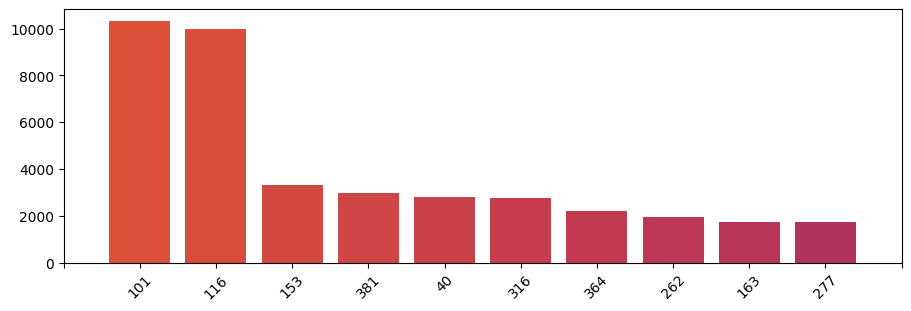

In [17]:
a = (df.groupby(['br'])['mortos'].sum()).sort_values(ascending=False)
plot_bar(a[:10])

- Como a proporção entre acidentes urbanos e rurais varia por região do Brasil?

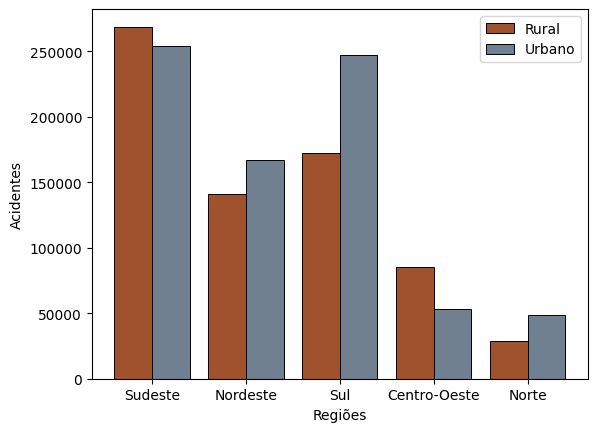

In [18]:
a = df.groupby(['regiao', 'uso_solo']).size()

r = list(df['regiao'].unique())

rrl = []
urb = []

for i in r:
    rrl.append(a[i]['Rural'])
    urb.append(a[i]['Urbano'])

l = len(r)

plt.bar(np.arange(len(r))-0.2, rrl, width=0.4, color='sienna',edgecolor='black', linewidth=0.7)
plt.bar(np.arange(len(r))+0.2, urb, width=0.4, color='slategrey', edgecolor='black', linewidth=0.7)

plt.xticks(np.arange(len(r)), labels=r)

plt.xlabel('Regiões')
plt.ylabel('Acidentes')

plt.legend(['Rural', 'Urbano'])

plt.show()


- Quais são as 10 causas mais frequentes de acidentes no Brasil?

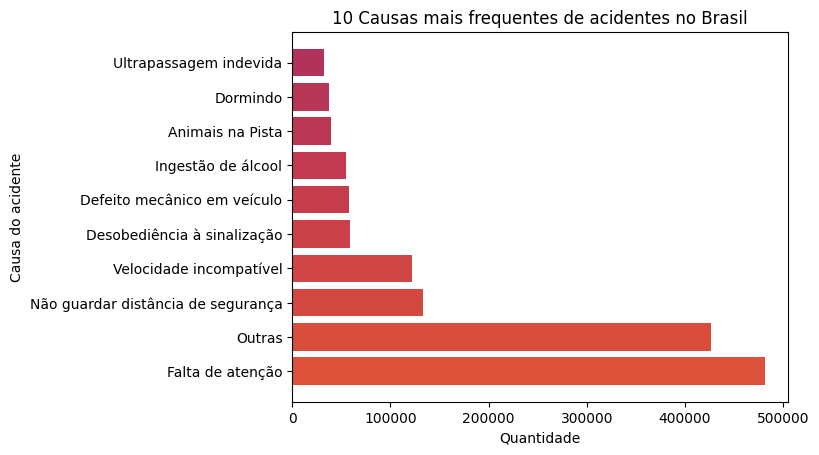

In [19]:
a = df.groupby(['causa_acidente'])['causa_acidente'].size().sort_values(ascending=False)[:10]

plt.barh(a.index, a.values, align='center', color=color1)
plt.ylabel('Causa do acidente')
plt.xlabel('Quantidade')
plt.title('10 Causas mais frequentes de acidentes no Brasil')
plt.show()

- A participação relativa de cada causa mudou ao longo dos anos?

Podemos observar que sim

In [20]:
n = df.groupby(['causa_acidente', 'ano']).size()
d = df.groupby(['causa_acidente']).size()
p = ((n/d)*100).round(2)
p.unstack(level=-1)

ano,2007,2008,2009,2010,2011,2012,2013,2014,2015
causa_acidente,,,,,,,,,
Animais na Pista,10.71,11.68,10.72,12.25,12.77,12.32,12.16,9.53,7.85
Defeito mecânico em veículo,9.35,10.13,10.41,12.01,12.08,11.82,12.39,11.91,9.91
Defeito na via,10.66,9.95,11.86,10.96,12.67,10.62,12.44,11.80,9.05
Desobediência à sinalização,6.87,7.81,8.79,12.17,13.30,13.24,13.73,13.88,10.22
Dormindo,9.05,8.96,8.98,11.85,11.86,12.45,12.99,12.90,10.95
Falta de atenção,8.78,9.63,10.83,12.66,13.21,12.73,13.07,11.45,7.65
Ingestão de álcool,5.63,6.46,8.73,12.35,13.72,13.78,13.66,13.41,12.24
Não guardar distância de segurança,6.09,7.29,8.59,11.67,12.96,14.07,16.14,14.66,8.53
Outras,10.77,11.71,13.02,13.33,13.25,11.62,10.33,9.14,6.81


- Acidentes em chuva são mais graves do que em tempo claro?

O que estamos fazendo na análise abaixo: 

Dado que um acidente ocorreu e a condição metereológica é x, a chance de um evento mais sério ocorrer aumenta?
    
Para isso, pegamos a quantidade de ocorrências que temos para uma determinada condição e medimos a chance pegando a quantidade que extraímos acima e dividindo pelo valor que acabamos de citar.

Por exemplo:


1000 acidentes fatais em dias ensolarados
500 acidentes  fatais em dias chuvosos

Podemos nos influenciar pelos valores absolutos e dizer: "Dias ensolarados tem mais acidentes fatais", porém, se vermos a quantidade de ocorrências que temos em dias ensolarados seria:

20.000 acidentes em dias ensolarados
1.000 acidentes em dias chuvosos

Ou seja, realizando a análise assim:

1000 / 20.000 = 5%

500 / 1.000 = 50%

Conclui-se então que o acidente em dias chuvosos tem mais chances de serem fatais nesse exemplo

Voltando para nosso caso, temos que o as chances para dias chuvosos são menores no geral se comparado aos dias com céu claro. Portanto a resposta é não.

In [21]:
n = df.groupby(['condicao_metereologica', 'classificacao_acidente']).size()
d = df.groupby(['condicao_metereologica']).size()
p = ((n/d)*100).round(2)
p.unstack(level=1, fill_value=0).loc[['Ceu Claro', 'Chuva']]

classificacao_acidente,Com Vítimas Fatais,Com Vítimas Feridas,Ignorado,Sem Vítimas
condicao_metereologica,,,,
Ceu Claro,4.46,37.81,0.72,57.01
Chuva,2.91,30.29,0.67,66.14


- A condição meteorológica influencia o tipo de acidente mais frequente? Sim!

In [22]:
n = df.groupby(['condicao_metereologica', 'tipo_acidente']).size()
d = df.groupby(['condicao_metereologica']).size()
p = ((n/d)*100).round(2)
p.unstack(level=0, fill_value=0)

condicao_metereologica,Ceu Claro,Chuva,Granizo,Ignorada,Neve,Nevoeiro/neblina,Nublado,Sol,Vento
tipo_acidente,,,,,,,,,
Atropelamento de animal,2.99,0.88,1.47,6.03,7.77,5.65,2.59,0.60,5.47
Atropelamento de pessoa,3.28,1.30,1.83,4.37,2.91,2.08,3.07,2.16,4.30
Capotamento,4.10,7.95,8.42,5.27,5.83,6.47,4.28,3.26,5.61
Colisão Transversal,10.82,5.85,4.40,8.23,6.80,7.54,10.20,12.31,8.57
Colisão com bicicleta,1.45,0.40,0.73,1.70,0.97,0.67,1.16,1.23,1.54
Colisão com objeto fixo,4.65,11.08,8.42,5.30,8.74,8.48,6.25,3.55,6.01
Colisão com objeto móvel,1.08,0.61,0.73,1.11,0.00,0.79,1.07,0.97,1.47
Colisão frontal,3.73,3.98,3.30,4.66,4.85,5.47,3.56,2.59,4.75
Colisão lateral,17.73,10.43,13.55,14.57,11.65,10.64,16.92,20.71,14.14


- Qual tipo de pista concentra mais acidentes fatais?


In [23]:
df.groupby(['tipo_pista', 'classificacao_acidente']).size().unstack(level=0).loc[['Com Vítimas Fatais']]

tipo_pista,Dupla,Múltipla,Simples
classificacao_acidente,,,
Com Vítimas Fatais,14445,2023,41024


- O traçado da via influencia a gravidade dos acidentes?

Podemos ver que sim

In [24]:
num = df.groupby(['tracado_via', 'classificacao_acidente']).size()
den = df.groupby('tracado_via').size()
res = ((num / den)*100).round(2)
res.unstack(level=0, fill_value=0)

tracado_via,Cruzamento,Curva,Reta
classificacao_acidente,,,
Com Vítimas Fatais,1.43,4.36,4.02
Com Vítimas Feridas,36.37,37.08,35.43
Ignorado,0.35,0.87,0.66
Sem Vítimas,61.84,57.69,59.89


- Existe um perfil de risco combinando tipo de pista, traçado e condição meteorológica?

Podemos ver que a reta é quem domina, independente da situação

In [25]:
num = df.groupby(['tracado_via', 'classificacao_acidente', 'condicao_metereologica']).size()
den = df.groupby(['condicao_metereologica', 'classificacao_acidente']).size()
res = ((num / den)*100).round(2)
res.unstack(level=0, fill_value=0)

tracado_via                                    Cruzamento  Curva    Reta
classificacao_acidente condicao_metereologica                           
Com Vítimas Fatais     Ceu Claro                     2.51  20.42   77.07
                       Chuva                         1.38  39.15   59.46
                       Granizo                       0.00  57.14   42.86
                       Ignorada                      1.25  19.50   79.25
                       Neve                          0.00   0.00  100.00
                       Nevoeiro/neblina              3.59  29.34   67.07
                       Nublado                       2.54  23.80   73.66
                       Sol                           3.40  24.40   72.20
                       Vento                         1.20  17.20   81.60
Com Vítimas Feridas    Ceu Claro                     6.86  18.16   74.98
                       Chuva                         3.80  40.19   56.01
                       Granizo                       0.00  34.21   65.79
                       Ignorada                      4.91  19.34   75.75
                       Neve                          2.56  25.64   71.79
                       Nevoeiro/neblina              5.63  33.11   61.26
                       Nublado                       7.43  22.05   70.52
                       Sol                           8.76  17.91   73.33
                       Vento                         6.07  16.28   77.65
Ignorado               Ceu Claro                     3.62  23.99   72.39
                       Chuva                         2.23  37.38   60.40
                       Granizo                       0.00   0.00  100.00
                       Ignorada                      3.99  28.34   67.66
                       Neve                          0.00   0.00  100.00
                       Nevoeiro/neblina              3.52  37.32   59.15
                       Nublado                       3.97  27.56   68.47
                       Sol                           3.03  26.16   70.81
                       Vento                         3.77  15.09   81.13
Sem Vítimas            Ceu Claro                     7.05  15.59   77.37
                       Chuva                         4.02  39.05   56.94
                       Granizo                       2.12  26.98   70.90
                       Ignorada                      5.15  17.77   77.08
                       Neve                          5.45  25.45   69.09
                       Nevoeiro/neblina              5.45  32.55   62.01
                       Nublado                       7.67  19.84   72.49
                       Sol                           9.49  13.74   76.77
                       Vento                         5.46  15.66   78.88

- O perfil de causas de acidentes mudou entre o início e o fim do período analisado?


In [26]:
df.groupby(['tipo_acidente', 'ano']).size().unstack(level=-1)

ano,2007,2008,2009,2010,2011,2012,2013,2014,2015
tipo_acidente,,,,,,,,,
Atropelamento de animal,3556,3868,3712,4250,4446,4287,4096,3174,2639
Atropelamento de pessoa,3852,4464,4797,5299,5089,4687,4420,4150,3662
Capotamento,6941,7240,7694,8576,8765,8415,7926,7424,6549
Colisão Transversal,11817,13245,14900,17747,19445,18720,18873,17935,13139
Colisão com bicicleta,2466,2406,2231,2280,2046,1714,1577,1346,1245
Colisão com objeto fixo,8183,8732,10546,11215,11383,10628,10060,9153,7621
Colisão com objeto móvel,1517,1604,1738,1960,1845,1731,1672,1372,912
Colisão frontal,4575,4741,5183,6234,6589,6473,6797,6873,5720
Colisão lateral,20367,23676,25829,30675,33213,31753,32256,27944,17034


- A letalidade dos acidentes melhorou ao longo do tempo em cada UF?

Podemos observar que sim, na maiora dos casos. Além disso, podemos observar o padrão seguindo a série temporal de acidentes ao longos dos anos que foi destacado anteriormente


In [27]:
df.groupby(['uf', 'ano'])['mortos'].sum().unstack(level=-1)

ano,2007,2008,2009,2010,2011,2012,2013,2014,2015
uf,,,,,,,,,
AC,20,13,31,14,23,21,23,32,20
AL,132,102,125,153,156,191,148,149,118
AM,12,11,11,18,34,19,18,18,15
AP,15,13,9,12,19,12,28,10,11
BA,605,660,638,812,779,849,799,794,642
CE,182,193,141,276,227,238,233,291,202
DF,67,49,43,41,63,71,40,46,47
ES,217,208,220,315,317,261,303,279,172
GO,325,391,451,515,510,519,504,468,442


- Existem picos atípicos de acidentes em datas específicas como feriados e carnaval?

Como podemos ver abaixo, temos um único comportamento atípico no final do ano, geralmente associados a data festivas como natal e ano novo, que normalmente há um consumo alto de álcool.

Apesar dos dados indicarem que não tem associação o álcool com as datas festivas, há um fato que o condutor pode recusar realizar o teste do bafômetro no momento da ocorrência, possibilitando um descarte dessa causa no momento da ocorrência.

Por fim, como para se pegar as datas festivas precisaríamos ir contando por ano as datas necessariamente, por haver mudanças, generalizei por mês.

In [28]:
df.groupby(['mes', 'causa_acidente']).size().unstack(level=0)

mes,1,2,3,4,5,6,7,8,9,10,11,12
causa_acidente,,,,,,,,,,,,
Animais na Pista,2996,2887,3195,3394,3667,3556,3677,3517,3266,3257,2780,3022
Defeito mecânico em veículo,4934,4691,5070,4786,4738,4377,4658,4647,4749,4869,4746,5541
Defeito na via,2164,2041,2252,2141,1998,1708,1938,1466,1376,1451,1501,1988
Desobediência à sinalização,4795,4285,4932,4914,5095,4903,5040,4831,4948,5106,4668,5312
Dormindo,3296,3000,3039,2784,2952,2926,2818,2855,3010,3256,3178,4032
Falta de atenção,39786,37147,39632,40374,41650,40061,41080,39548,39134,39926,38145,44453
Ingestão de álcool,3832,3868,4554,4497,5082,4750,4679,4720,4645,4612,4572,5281
Não guardar distância de segurança,12142,10659,11111,11812,11295,10716,11112,10443,10377,10330,10544,13072
Outras,36369,32597,36248,34982,35673,34353,35453,33443,34339,36600,35610,40842


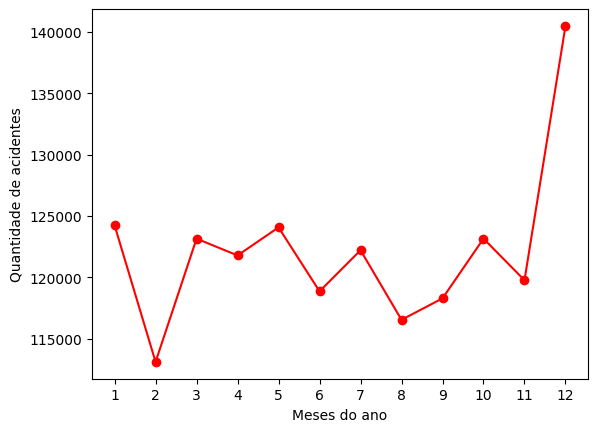

In [29]:
a = df.groupby(['mes']).size()

fig = plt.figure()

ax = fig.add_subplot()

ax.plot(a.index, a.values, '-ro')

plt.xlabel('Meses do ano')
plt.ylabel('Quantidade de acidentes')

ax.set(xticks=np.arange(1, len((a.index))+1))

plt.show()

- Quais UFs apresentam comportamento atípico em relação à média nacional de fatalidade?

MA, TO e RR representam os mais atípicos, curiosamente estados mais ao norte do país

In [30]:
df['mortos'].mean().round(2)

np.float64(0.05)

In [31]:
(df.groupby(['uf'])['mortos'].mean()).round(2).sort_values(ascending=False)


uf
MA    0.11
RR    0.11
TO    0.10
AM    0.09
PI    0.08
BA    0.08
CE    0.07
MT    0.07
AL    0.07
AP    0.07
GO    0.06
PE    0.06
SE    0.06
MS    0.06
AC    0.05
PA    0.05
RN    0.05
MG    0.05
PB    0.05
ES    0.04
DF    0.04
RO    0.04
PR    0.04
RJ    0.03
RS    0.03
SC    0.03
SP    0.03
Name: mortos, dtype: float64